In [8]:
# cell 1 — imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path

# style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# connection
DB_PATH = Path("../data/database/steam.db")
conn = sqlite3.connect(DB_PATH)

# load main tables
games = pd.read_sql("SELECT * FROM games", conn)
genres = pd.read_sql("SELECT * FROM game_genres", conn)
tags = pd.read_sql("SELECT * FROM game_tags", conn)

# load processed CSVs from SQL analysis
genre_perf = pd.read_csv("../data/processed/genre_performance.csv")
price_tiers = pd.read_csv("../data/processed/price_tiers.csv")
tag_rankings = pd.read_csv("../data/processed/tag_rankings.csv")
dev_comparison = pd.read_csv("../data/processed/developer_comparison.csv")

print(f"games: {games.shape}")
print(f"genres: {genres.shape}")
print(f"tags: {tags.shape}")
print("All data loaded")

games: (27075, 19)
genres: (76462, 2)
tags: (78002, 2)
All data loaded


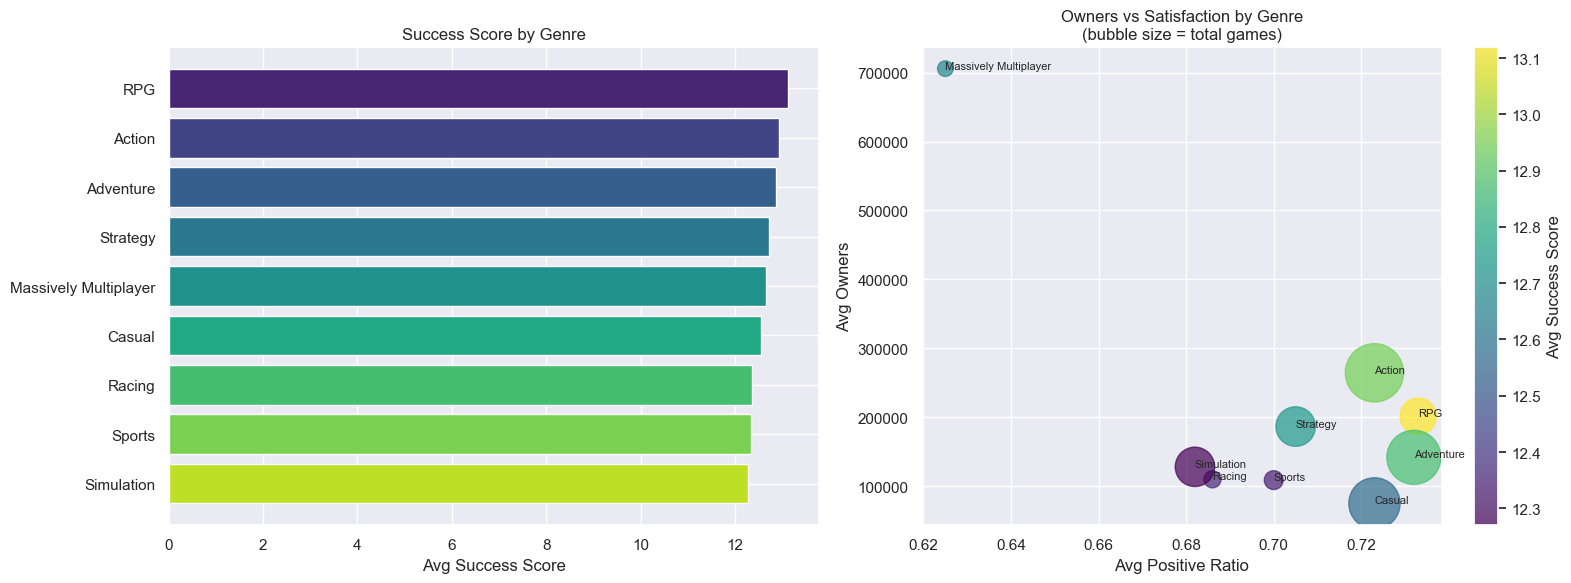

Saved


In [9]:
# cell 2 — genre performance bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# left — avg success score by genre
axes[0].barh(genre_perf['genre'], genre_perf['avg_success_score'], 
             color=sns.color_palette("viridis", len(genre_perf)))
axes[0].set_xlabel("Avg Success Score")
axes[0].set_title("Success Score by Genre")
axes[0].invert_yaxis()

# right — avg owners vs positive ratio (bubble = total games)
scatter = axes[1].scatter(
    genre_perf['avg_positive_ratio'],
    genre_perf['avg_owners'],
    s=genre_perf['total_games'] / 5,
    c=genre_perf['avg_success_score'],
    cmap='viridis',
    alpha=0.7
)
plt.colorbar(scatter, ax=axes[1], label='Avg Success Score')

for _, row in genre_perf.iterrows():
    axes[1].annotate(row['genre'], 
                    (row['avg_positive_ratio'], row['avg_owners']),
                    fontsize=8, ha='left')

axes[1].set_xlabel("Avg Positive Ratio")
axes[1].set_ylabel("Avg Owners")
axes[1].set_title("Owners vs Satisfaction by Genre\n(bubble size = total games)")

plt.tight_layout()
plt.savefig("../reports/01_genre_performance.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

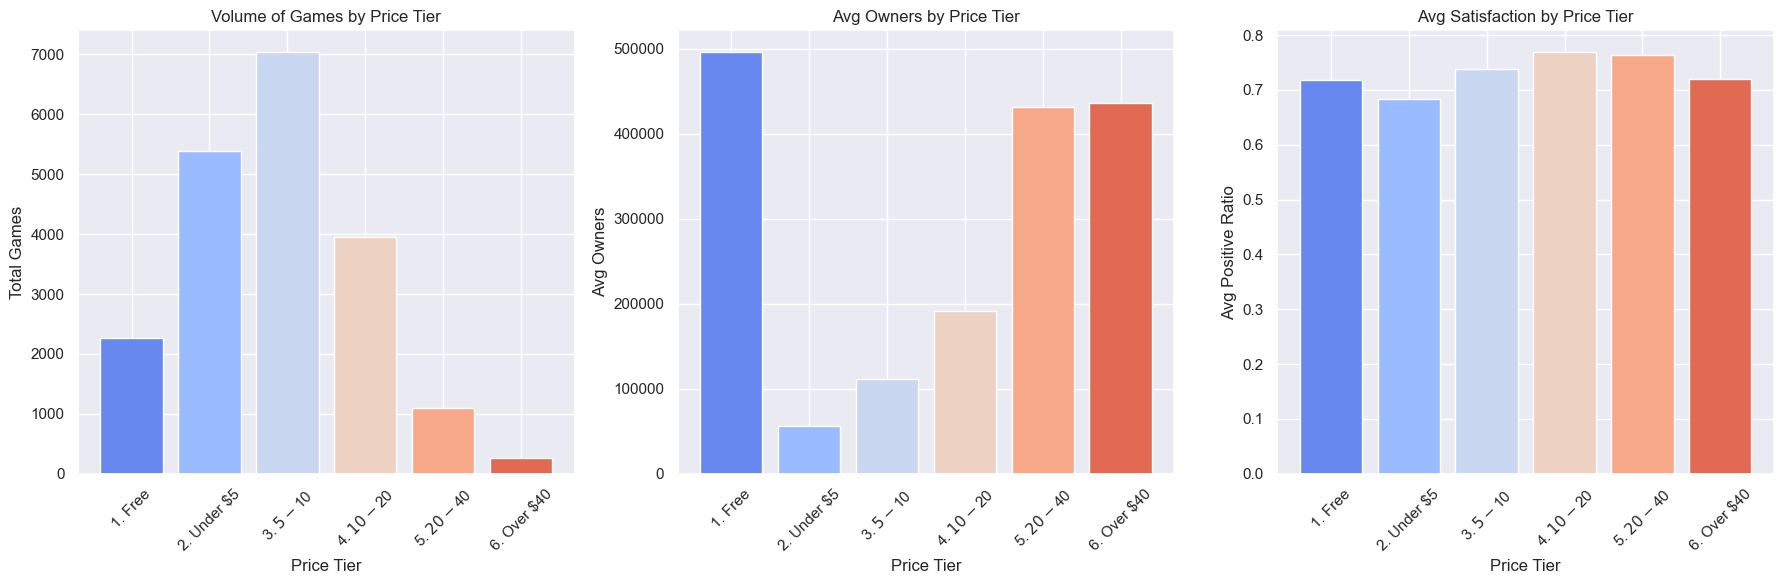

Saved


In [10]:
# cell 3 — price tier analysis chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# left — total games per tier
axes[0].bar(price_tiers['price_tier'], price_tiers['total_games'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[0].set_xlabel("Price Tier")
axes[0].set_ylabel("Total Games")
axes[0].set_title("Volume of Games by Price Tier")
axes[0].tick_params(axis='x', rotation=45)

# middle — avg owners per tier
axes[1].bar(price_tiers['price_tier'], price_tiers['avg_owners'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[1].set_xlabel("Price Tier")
axes[1].set_ylabel("Avg Owners")
axes[1].set_title("Avg Owners by Price Tier")
axes[1].tick_params(axis='x', rotation=45)

# right — avg positive ratio per tier
axes[2].bar(price_tiers['price_tier'], price_tiers['avg_positive_ratio'],
            color=sns.color_palette("coolwarm", len(price_tiers)))
axes[2].set_xlabel("Price Tier")
axes[2].set_ylabel("Avg Positive Ratio")
axes[2].set_title("Avg Satisfaction by Price Tier")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../reports/02_price_tiers.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

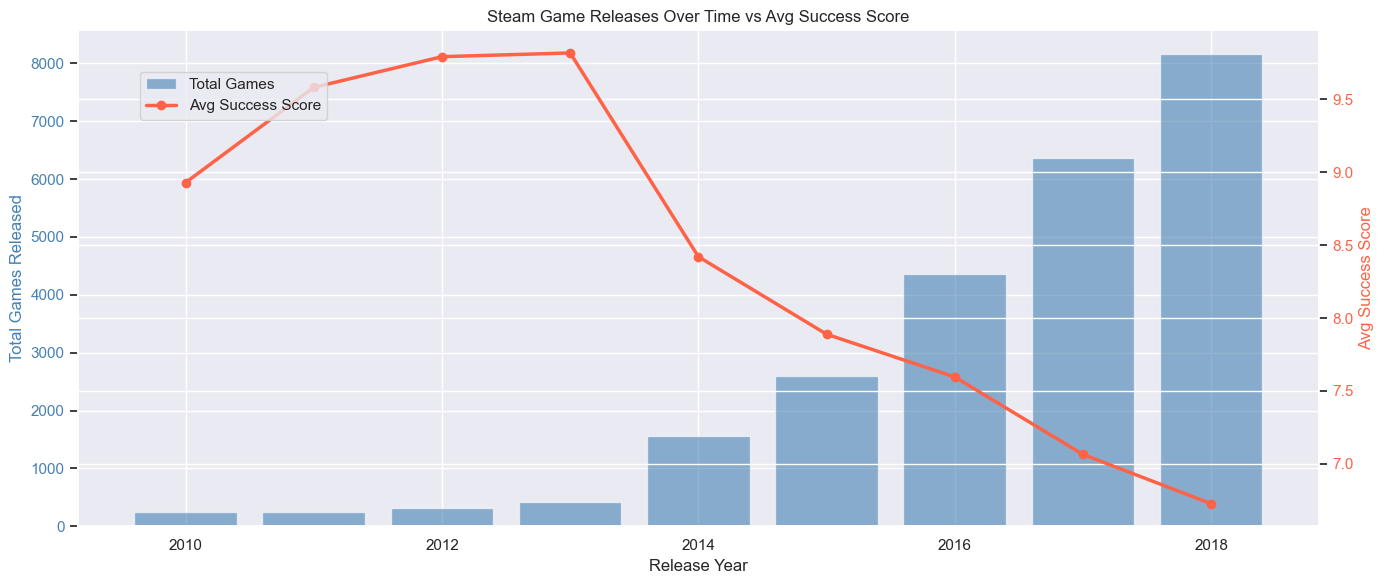

Saved


In [11]:

# cell 4 updated — filter to 2010 onwards for meaningful trend
yearly = games[games['release_year'].between(2010, 2018)].groupby('release_year').agg(
    total_games=('appid', 'count'),
    avg_success_score=('success_score', 'mean'),
    avg_positive_ratio=('positive_ratio', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

# bar chart — volume
ax1.bar(yearly['release_year'], yearly['total_games'], 
        color='steelblue', alpha=0.6, label='Total Games')
ax1.set_xlabel("Release Year")
ax1.set_ylabel("Total Games Released", color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# line chart overlay — avg success score
ax2 = ax1.twinx()
ax2.plot(yearly['release_year'], yearly['avg_success_score'], 
         color='tomato', linewidth=2.5, marker='o', label='Avg Success Score')
ax2.set_ylabel("Avg Success Score", color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

plt.title("Steam Game Releases Over Time vs Avg Success Score")
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig("../reports/03_yearly_trend.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

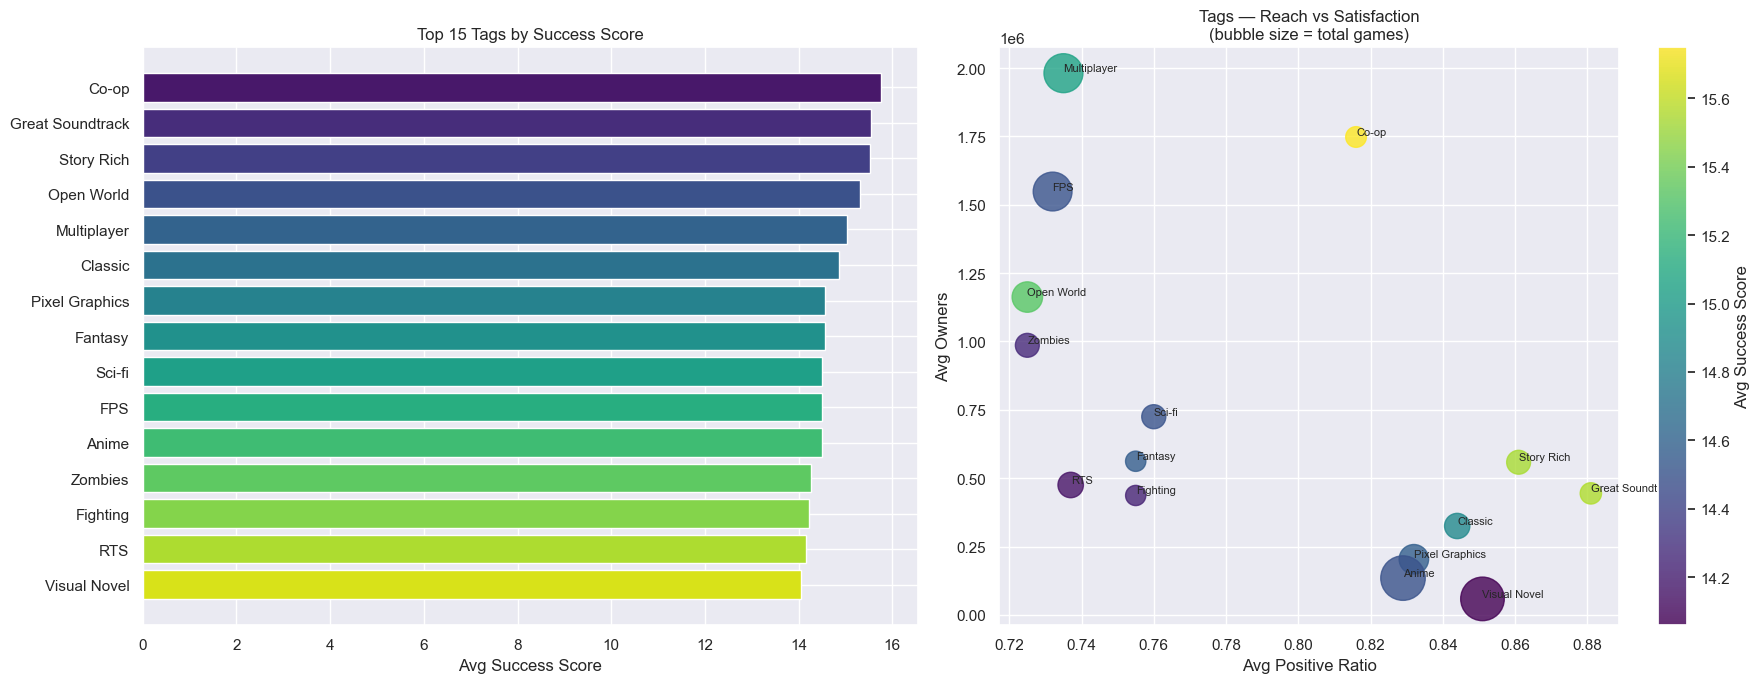

Saved


In [12]:
# cell 5 — top 15 tags by success score
top_tags = tag_rankings.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# left — success score ranking
colors = sns.color_palette("viridis", len(top_tags))
axes[0].barh(top_tags['tag'], top_tags['avg_success_score'], color=colors)
axes[0].invert_yaxis()
axes[0].set_xlabel("Avg Success Score")
axes[0].set_title("Top 15 Tags by Success Score")

# right — owners vs positive ratio scatter
scatter = axes[1].scatter(
    top_tags['avg_positive_ratio'],
    top_tags['avg_owners'],
    s=top_tags['total_games'] * 2,
    c=top_tags['avg_success_score'],
    cmap='viridis',
    alpha=0.8
)
plt.colorbar(scatter, ax=axes[1], label='Avg Success Score')

for _, row in top_tags.iterrows():
    axes[1].annotate(row['tag'],
                    (row['avg_positive_ratio'], row['avg_owners']),
                    fontsize=8, ha='left', va='bottom')

axes[1].set_xlabel("Avg Positive Ratio")
axes[1].set_ylabel("Avg Owners")
axes[1].set_title("Tags — Reach vs Satisfaction\n(bubble size = total games)")

plt.tight_layout()
plt.savefig("../reports/04_tag_rankings.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

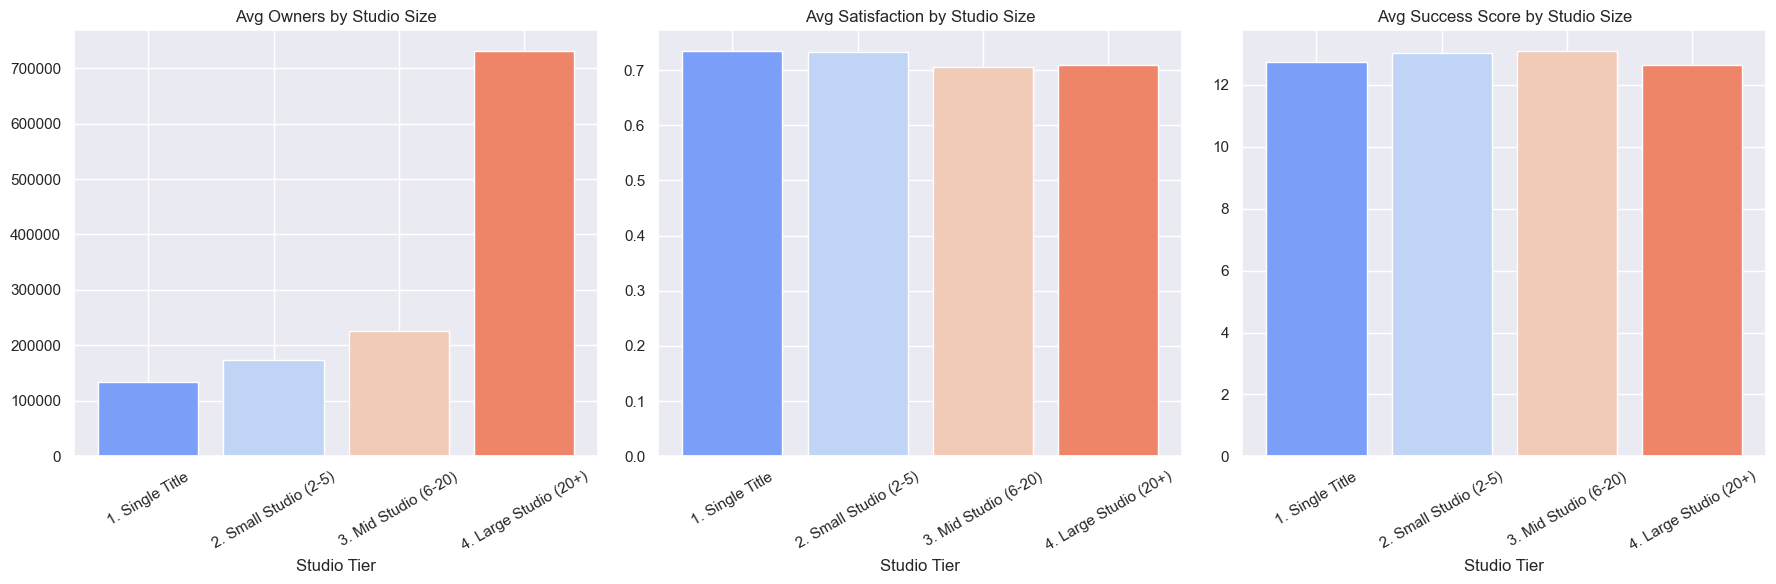

Saved


In [13]:
# cell 6 — developer tier comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['avg_owners', 'avg_positive_ratio', 'avg_success_score']
titles = ['Avg Owners by Studio Size', 
          'Avg Satisfaction by Studio Size', 
          'Avg Success Score by Studio Size']
colors = sns.color_palette("coolwarm", len(dev_comparison))

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].bar(dev_comparison['studio_tier'], dev_comparison[metric], color=colors)
    axes[i].set_title(title)
    axes[i].set_xlabel("Studio Tier")
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig("../reports/05_developer_tiers.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")

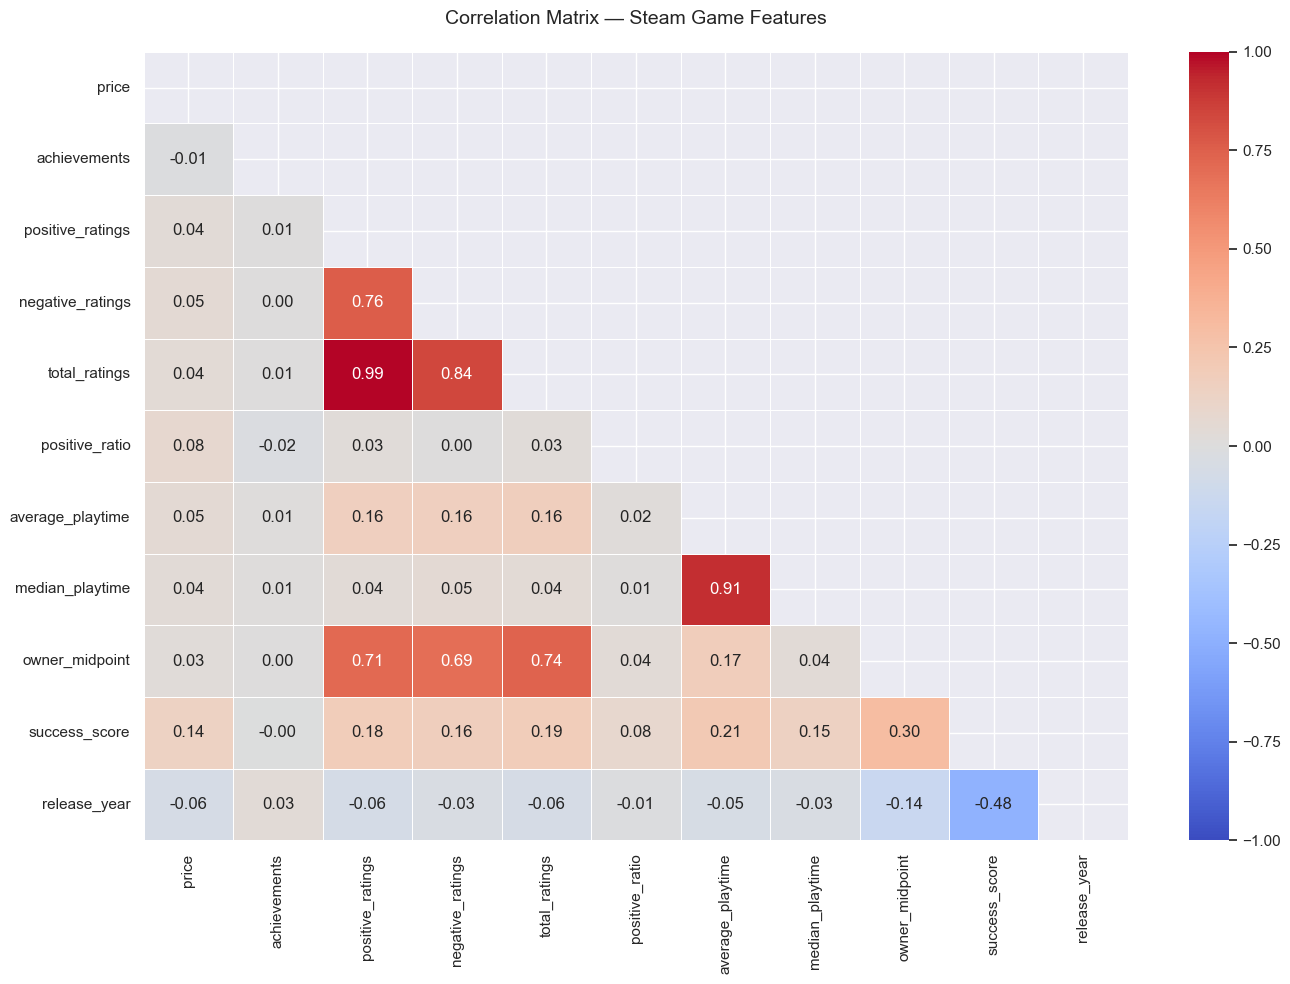

Saved


In [14]:
# cell 7 — correlation heatmap
numeric_cols = [
    'price', 'achievements', 'positive_ratings', 'negative_ratings',
    'total_ratings', 'positive_ratio', 'average_playtime', 'median_playtime',
    'owner_midpoint', 'success_score', 'release_year'
]

corr_matrix = games[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)

ax.set_title("Correlation Matrix — Steam Game Features", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("../reports/06_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved")